# Hyperparamter tuning

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

## Dataset

We're going to use a different dataset this time, which is more interesting than flowers I hope.

[https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

In [2]:
base_feature_names = [
    'radius',
    'texture',
    'perimeter',
    'area',
    'smoothness',
    'compactness',
    'concavity',
    'concave_points',
    'symmetry',
    'fractal_dimension',
]

feature_names = []
for i in range(1, 4):
    for feature in base_feature_names:
        feature_names.append(feature + str(i))

feature_names

['radius1',
 'texture1',
 'perimeter1',
 'area1',
 'smoothness1',
 'compactness1',
 'concavity1',
 'concave_points1',
 'symmetry1',
 'fractal_dimension1',
 'radius2',
 'texture2',
 'perimeter2',
 'area2',
 'smoothness2',
 'compactness2',
 'concavity2',
 'concave_points2',
 'symmetry2',
 'fractal_dimension2',
 'radius3',
 'texture3',
 'perimeter3',
 'area3',
 'smoothness3',
 'compactness3',
 'concavity3',
 'concave_points3',
 'symmetry3',
 'fractal_dimension3']

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', 
                 header=None, index_col=0, names=['Diagnosis', *feature_names])

print(f"Loaded the Wisconsin Breast Cancer dataset of size {df.shape}")
df.head()

Loaded the Wisconsin Breast Cancer dataset of size (569, 31)


,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Now we need to get our dataset, that is our `X, y` variables. Make sure to encode the benign/malignant labels into `[0, 1]` labels

In [4]:
# Preprocess all the data
X = df.iloc[:, 1:].values # All numerical features about the mass
y = df.iloc[:, 0].values # M for malignant, B for benign

# Encode the categorical labels
y_enc = np.zeros(y.shape)
y_enc[y == 'M'] = 1.

# Count the number of each class
print(f"There are {(y_enc==0).sum()} benign samples and {(y_enc==1).sum()} malignant samples")

There are 357 benign samples and 212 malignant samples


This will be a bit harder to visualize since we don't have 30-dimensional brains. First, visualize the features in a 2-D space using PCA

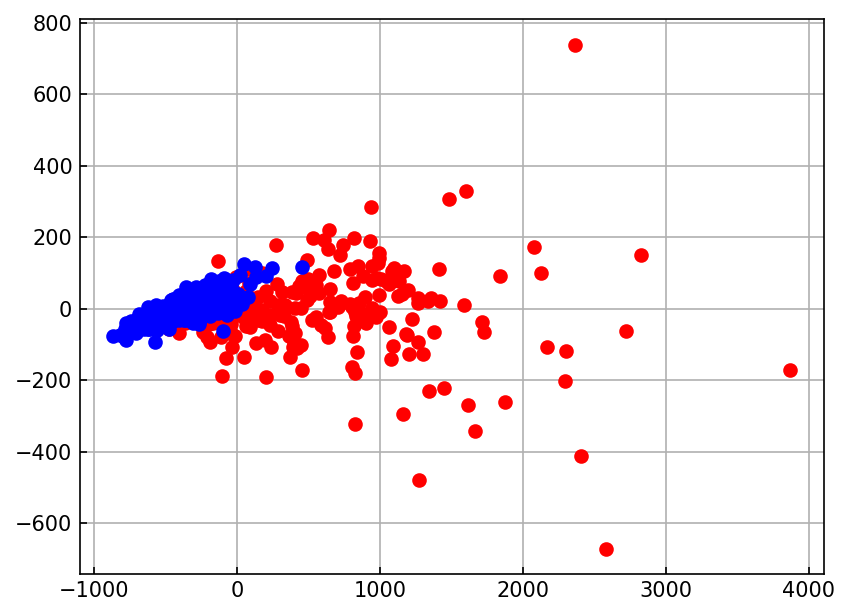

In [5]:
from sklearn.decomposition import PCA

def scatter_benign_malignant(ax, X, y, pca, label='Train', **kwargs):
    z = pca.transform(X)
    mask = y == 1
    ax.scatter(z[mask, 0], z[mask, 1], color='red', label=f'Malignant ({label})', **kwargs)
    ax.scatter(z[~mask, 0], z[~mask, 1], color='blue', label=f'Benign ({label})', **kwargs)

pca = PCA(n_components=2).fit(X)
ax = plt.figure().gca()
scatter_benign_malignant(ax, X, y_enc, pca)

Next, use `seaborn` to plot the feature correlation matrix

Text(0.5, 1.0, 'Feature correlation matrix')

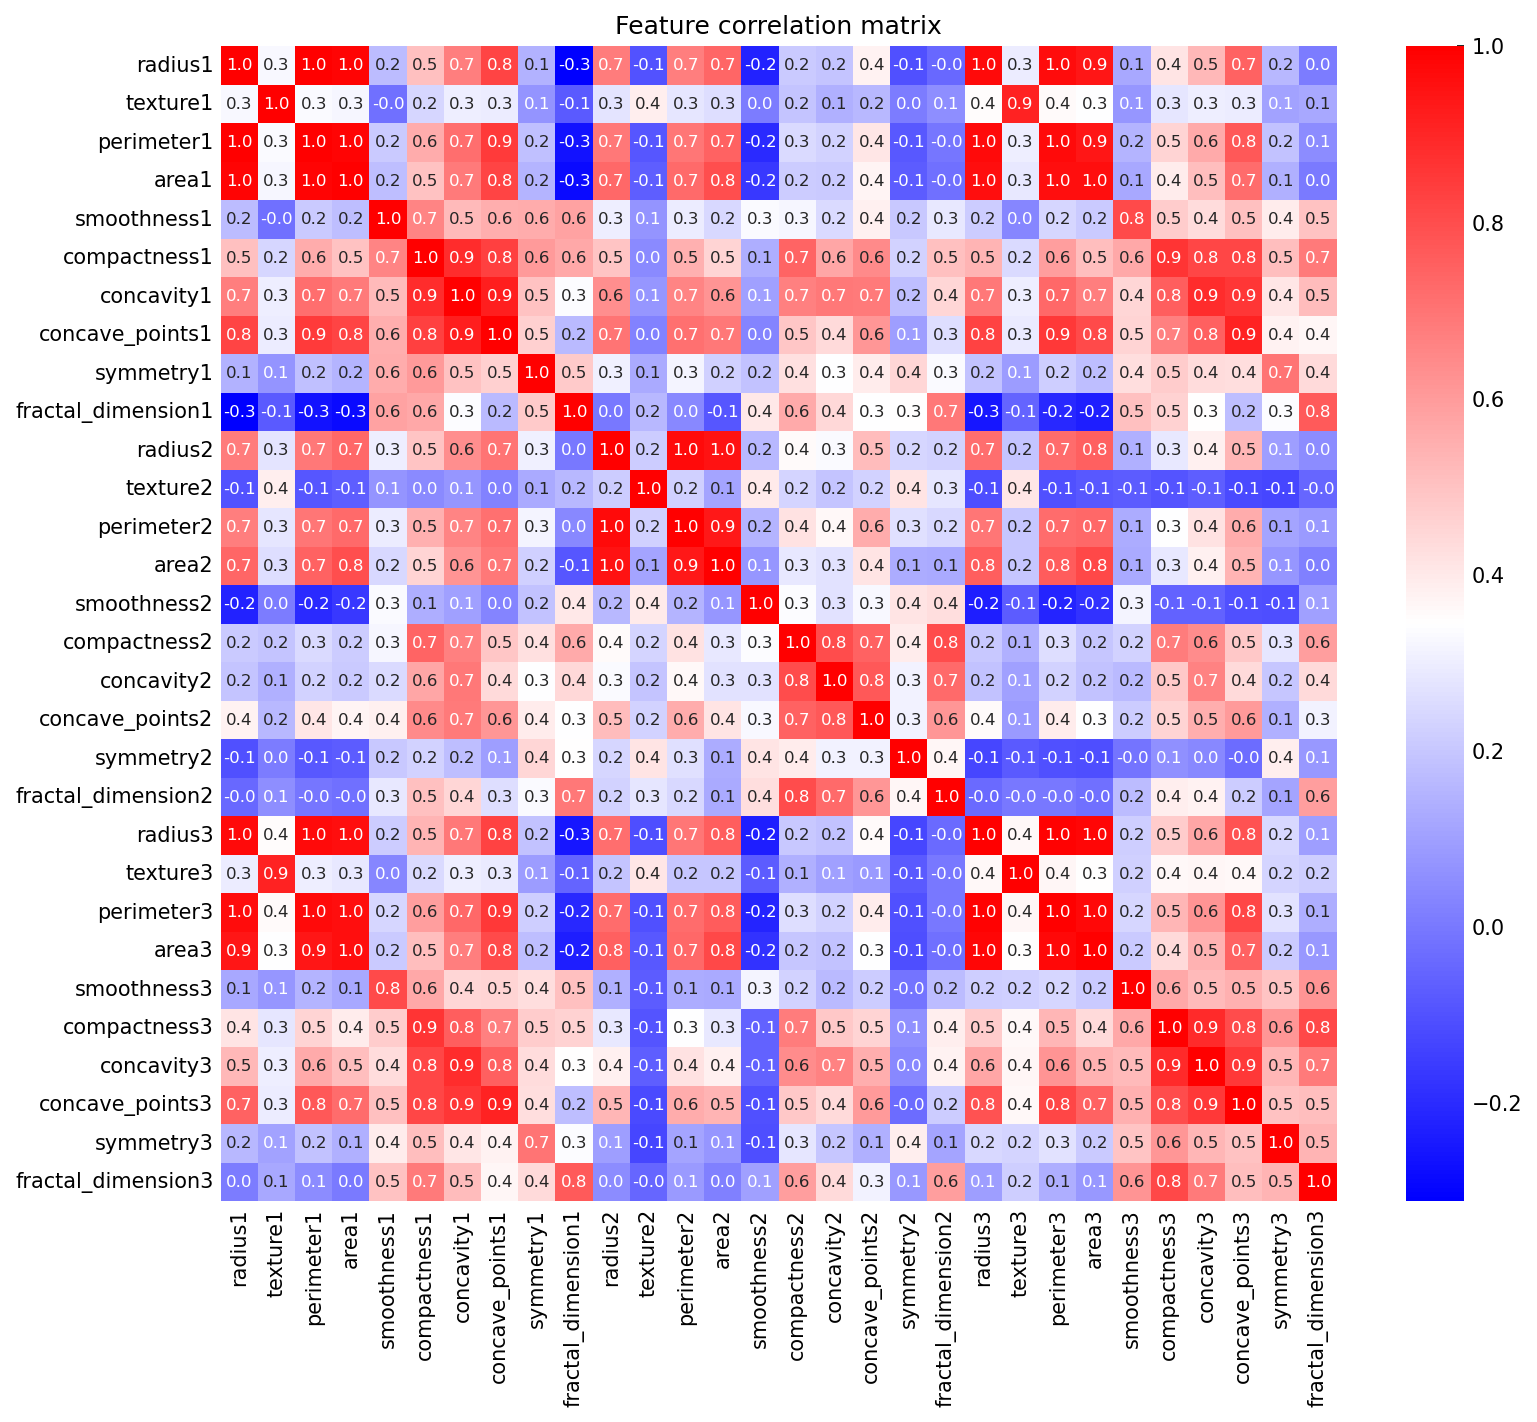

In [6]:
import seaborn as sns
ax = plt.figure(figsize=(12,10)).gca()
sns.heatmap(df.iloc[:, 1:].corr(),
            annot=True,
            cmap='bwr',
            fmt='.1f',
            annot_kws={'size': 8},
            ax=ax)
ax.set_title('Feature correlation matrix')

Finally, we should create and plot three subsets of our dataset:

- Training dataset, for model fitting
- Validation dataset, to track model fitting
- Test dataset, to evaluate our model

In [7]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)
print(f"The training set has size {X_train.shape}")
print(f"The validation set has size {X_train.shape}")
print(f"The testing set has size {X_test.shape}")

The training set has size (364, 30)
The validation set has size (364, 30)
The testing set has size (114, 30)


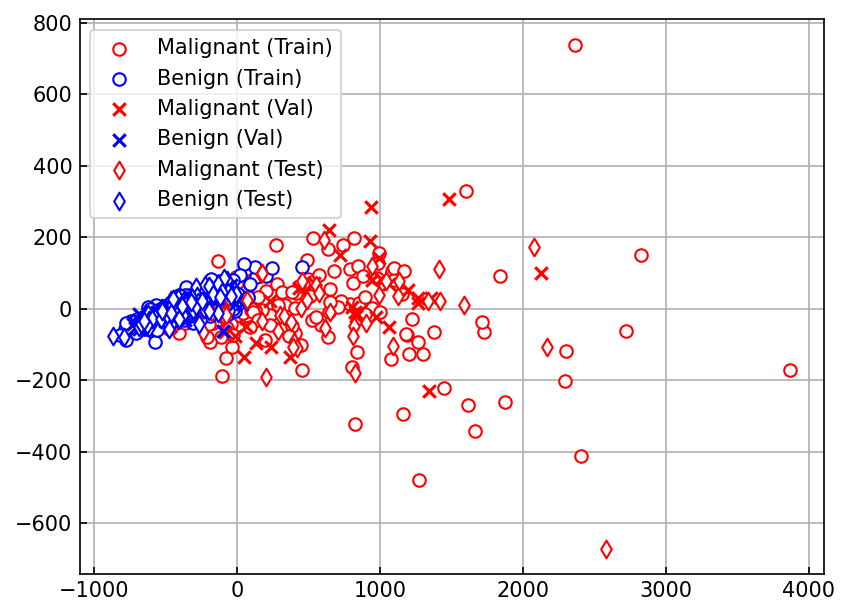

In [8]:
# Visualize train, validation, and test sets
ax = plt.figure().gca()
scatter_benign_malignant(ax, X_train, y_train, pca, marker='o', label='Train', facecolor='white')
scatter_benign_malignant(ax, X_val, y_val, pca, marker='x', label='Val')
scatter_benign_malignant(ax, X_test, y_test, pca, marker='d', label='Test', facecolor='white')

ax.legend()

## Define Polynomial Logistic Regression with L1 and L2 regularization

In [9]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

def cross_entropy(y_true, y_pred, eps=1e-10):
    return -np.mean(
        y_true * np.log(y_pred + eps) + \
        (1 - y_true) * np.log(1 - y_pred + eps)
    )
    
class LogisticRegression:
    def __init__(self,
                 lr=0.25,
                 num_epochs=500,
                 degree=1,
                 random_seed=42,
                 l1_weight=0.,
                 l2_weight=0.):
        self.lr = lr
        self.num_epochs = num_epochs
        self.degree = degree
        self.random_seed = random_seed
        self.l1_weight = l1_weight
        self.l2_weight = l2_weight

    def _preprocess(self, X):
        return self.poly_.transform(
            self.scaler_.transform(X)
        )

    def _preactivation(self, X):
        return np.dot(X, self.w_) + self.b_

    def _activation(self, z):
        return 1. / (1 + np.exp(-np.clip(z, -250, 250)))

    def _fit_epoch(self, X_train, y_train):
        X_prep = self._preprocess(X_train)
        z_pred = self._preactivation(X_prep)
        y_pred = self._activation(z_pred)

        diff = y_train - y_pred
        self.w_ += self.lr * diff.dot(X_prep) / X.shape[0] - \
            self.lr * self.l1_weight * np.sign(self.w_) - \
            self.lr * self.l2_weight * self.w_
        self.b_ += self.lr * diff.sum() / X.shape[0]

        train_loss = cross_entropy(y_train, y_pred)
        return train_loss
    
    def fit(self, X_train, y_train, X_val, y_val):
        np.random.seed(self.random_seed)
        self.poly_ = PolynomialFeatures(degree=self.degree, include_bias=False)
        self.poly_.fit(X)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X)

        self.w_ = np.random.normal(loc=0, scale=0.01, 
                                   size=self.poly_.n_output_features_)
        self.b_ = np.float32(0.)

        self.train_loss = []
        self.val_loss = []
        # iterate over epochs
        for _ in range(self.num_epochs):
            train_loss = self._fit_epoch(X_train, y_train)
            self.train_loss.append(train_loss)
            self.val_loss.append(
                 cross_entropy(
                     y_val,
                     self.predict_proba(X_val),
                 )
             )

        return self
    
    def predict_proba(self, X):
        """ Compute the class probability and return, for ROC-AUC """
        X_prep = self._preprocess(X)
        z_pred = self._preactivation(X_prep)
        y_pred = self._activation(z_pred)
        return y_pred
        
    def predict(self, X):
        y_pred = self.predict_proba(X)
        return np.where(y_pred > 0.5, 1, 0)
        
    def score(self, X, y):
        """ Compute accuracy - what fraction do we predict correctly? """
        y_pred = self.predict(X)
        return (y == y_pred).mean()

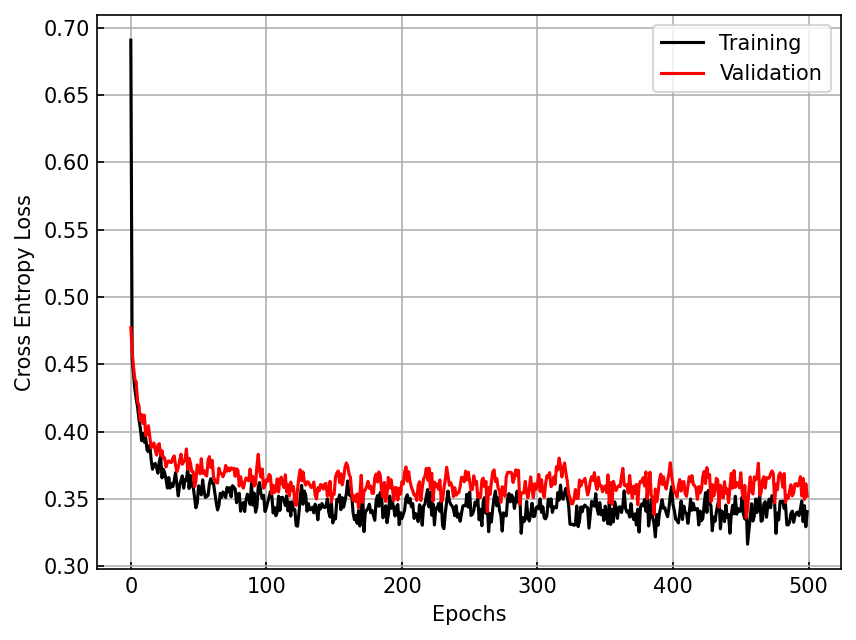

In [10]:
# Fit model, plot loss curves
model = LogisticRegression(degree=1, l1_weight=0.1)
model.fit(X_train, y_train, X_val, y_val)

ax = plt.figure().gca()
ax.plot(model.train_loss, color='black', label='Training')
ax.plot(model.val_loss, color='red', label='Validation')
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='linear');
ax.legend();

In [11]:
# Compare accuracy on training, validation, and testing sets
print('Training accuracy', model.score(X_train, y_train))
print('Validation accuracy', model.score(X_val, y_val))
print('Test accuracy', model.score(X_test, y_test))

Training accuracy 0.9120879120879121
Validation accuracy 0.945054945054945
Test accuracy 0.9385964912280702


<Axes: xlabel='PC 1', ylabel='PC 2'>

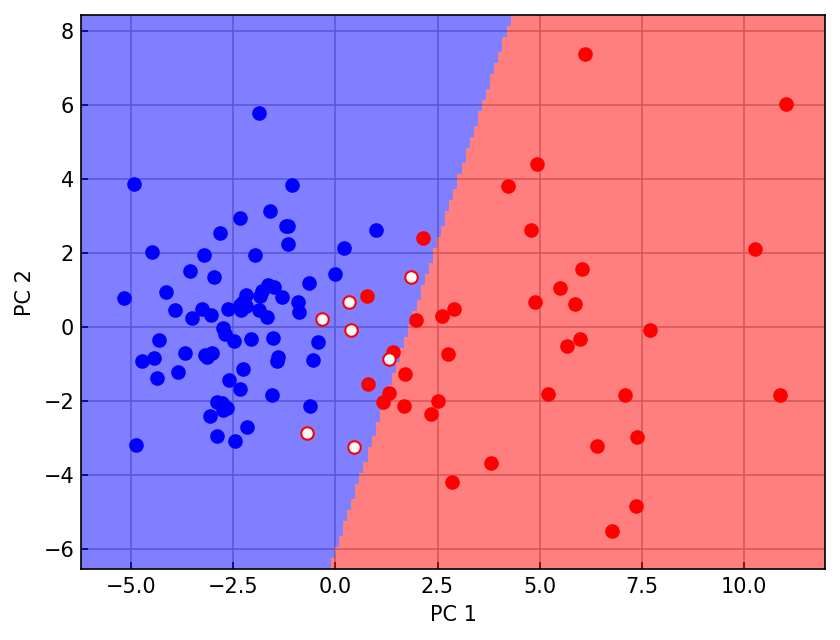

In [12]:
# Plot the decision boundary in a PCA space using the helper function below
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

def plot_PCA_decision_boundary(ax, X, y, model, d=0.1, colors=['blue', 'red']):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(model.scaler_.transform(X))

    x1, x2 = np.meshgrid(
        np.arange(X_pca[:, 0].min()-10*d, X_pca[:, 0].max()+10*d, d),
        np.arange(X_pca[:, 1].min()-10*d, X_pca[:, 1].max()+10*d, d),
    )
    grid_pca = np.stack([x1.ravel(), x2.ravel()]).T

    grid_raw = model.scaler_.inverse_transform(pca.inverse_transform(grid_pca))
    y_model = model.predict(grid_raw)
    y_model = y_model.reshape(x1.shape)

    pred_mask = model.predict(X) == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X_pca[label_mask & pred_mask, 0], X_pca[label_mask & pred_mask, 1], 
                   facecolor=colors[ii], edgecolor=colors[ii])
        ax.scatter(X_pca[label_mask & ~pred_mask, 0], X_pca[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[ii])
    ax.set(xlabel='PC 1', ylabel='PC 2')
    return ax

ax = plt.figure().gca()
plot_PCA_decision_boundary(ax, X_test, y_test, model)

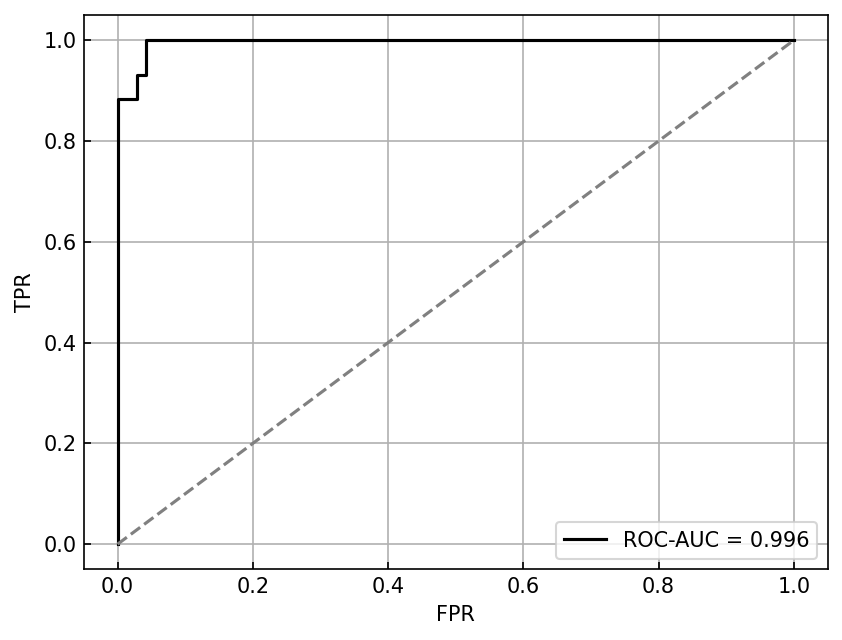

In [13]:
# Compute and plot a ROC curve
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

ax = plt.figure().gca()
ax.plot(fpr, tpr, color='black', label=f'ROC-AUC = {roc_auc:.3f}')
ax.plot([0,1], [0,1], color='grey', linestyle='--') # Chance level
ax.set(xlabel='FPR', ylabel='TPR')
ax.legend();

## K-fold cross validation

Before, we only used one validation set to estimate performance during training. But this is a partial snapshot. The idea behind cross-validation is you create several distinct train/val splits so that you have a performance estimate over the entire training set. 

Using cross-validation, you can more accurately assess and tune model hyperparameters before applying the model to test data

In [14]:
from sklearn.model_selection import KFold, StratifiedKFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracy = []

model = LogisticRegression(degree=1)


for k, (train_idx, val_idx) in enumerate(kfold.split(X_train_val, y_train_val)):
    X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
    X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]

    mal_frac_train = np.sum(y_train == 1) / y_train.shape[0]
    print(f'Fold {k} has {mal_frac_train * 100:.0f}% malignant samples')

    model.fit(X_train, y_train, X_val, y_val)
    val_acc = model.score(X_val, y_val)
    print(f'\tValidation accuracy = {val_acc:.3f}')
    print()

    fold_accuracy.append(val_acc)

Fold 0 has 37% malignant samples
	Validation accuracy = 0.967

Fold 1 has 38% malignant samples
	Validation accuracy = 0.989

Fold 2 has 35% malignant samples
	Validation accuracy = 0.967

Fold 3 has 38% malignant samples
	Validation accuracy = 0.967

Fold 4 has 38% malignant samples
	Validation accuracy = 0.989



In [15]:
print(f"Cross-validation accuracy = {np.mean(fold_accuracy):.3f} +/- {np.std(fold_accuracy):.3f}")
print(f"Test accuracy = {model.score(X_test, y_test):.3f}")

Cross-validation accuracy = 0.976 +/- 0.011
Test accuracy = 0.982


## Hyperparameter tuning with cross validation

We want to get the training parameters `lr`, `l1_weight` that will maximize our generalization accuracy. To do this, we can do a grid search and track the cross-validation accuracy for each parameter combination

In [16]:
from itertools import product

l1_grid = np.geomspace(1e-4, 1, 5)
lr_grid = np.geomspace(1e-3, 1, 5)

tracking = pd.DataFrame(columns=['l1_weight', 'lr', 'fold', 'score'])
model = LogisticRegression(degree=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for lr, l1_weight in product(lr_grid, l1_grid):
    model.lr = lr
    model.l1_weight = l1_weight

    for k, (train_idx, val_idx) in enumerate(cv.split(X_train_val, y_train_val)):
        X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
        X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]
        model.fit(X_train, y_train, X_val, y_val)
        val_acc = model.score(X_val, y_val)

        tracking.loc[len(tracking)] = {
            'l1_weight': l1_weight,
            'lr': lr,
            'fold': k,
            'score': val_acc
        }

In [17]:
param_df = tracking.groupby(['l1_weight', 'lr']) \
    .agg({'score': 'mean'}) \
    .reset_index() \
    .sort_values('score', ascending=False)

best = param_df.iloc[0]

print(f"The best estimator had parameters lr = {best.lr:.3f} and l1_weight = {best.l1_weight:.3f}"
      f" and reached an average validation accuracy of {best.score:.3f}")

The best estimator had parameters lr = 0.178 and l1_weight = 0.001 and reached an average validation accuracy of 0.976


In [18]:
model.lr = best['lr']
model.l1_weight = best['l1_weight']
model.fit(X_train_val, y_train_val, X_val, y_val)
test_acc = model.score(X_test, y_test)
print(f"This estimator reaches a test accuracy of {test_acc:.3f}")

This estimator reaches a test accuracy of 0.982


# Nonlinear optimization and kernel methods

We have seen with Polynomial Logistic Regression that the use of nonlinear features can allow us to represent more complex functions and decision boundaries. Here, we will compare linear ridge (L2) regression with nonlinear features $\phi(x)$ to **kernel ridge regression** (KRR). KRR represents the inner product $\langle \phi(x), \phi(y) \rangle$ via a **kernel function** $k(x, y)$. 

At first this may seem uninteresting. What is the point of using a function to represent a dot product? Let's consider 2-dimensional inputs $\mathbf{x} = (x_1, x_2)$ and $\mathbf{y} = (y_1, y_2)$. 

Some kernel functions are uninteresting, like the linear kernel: $k_1(\mathbf{x}, \mathbf{y}) = \mathbf{x} \cdot \mathbf{y} = x_1 \,y_1 + x_2 \,y_2$

Some are slightly more interesting, like the quadratic kernel:
\begin{align}
k_2(\mathbf{x}, \mathbf{y}) 
&= (\mathbf{x} \cdot \mathbf{y})^2 \\
&= (x_1 \, y_1 + x_2 \, y_2)^2 \\
&= x_1^2 \, y_1^2 + x_2^2 \, y_2^2 + 2 x_1 \, x_2 \, y_1 \, y_2 \\
&= (x_1^2,\, x_2^2,\, x_1\, x_2 \sqrt{2}) \cdot (y_1^2,\, y_2^2,\, y_1\, y_2 \sqrt{2})
\end{align}
Here, the quadratic kernel allows us to compute a dot product between two 3-dimensional feature vectors, *but we did not have to actually compute either feature vector!*

One of the most interesting kernels is the RBF kernel:
\begin{align}
    k_{\text{RBF}}(\mathbf{x}, \mathbf{y}) = \exp \left(-\frac12 \Vert \mathbf{x} - \mathbf{y} \Vert^2 \right)
\end{align}
It turns out that this is equivalent to the product of two *infinite*-dimensional feature vectors (read more [here](https://en.wikipedia.org/wiki/Radial_basis_function_kernel)). The RBF kernel is particularly convenient because we do not have the computational resources to compute an infinite-size feature vector for each element of our dataset. But computing the kernel is very easy, and can allow us to represent a variety of complex behaviors.

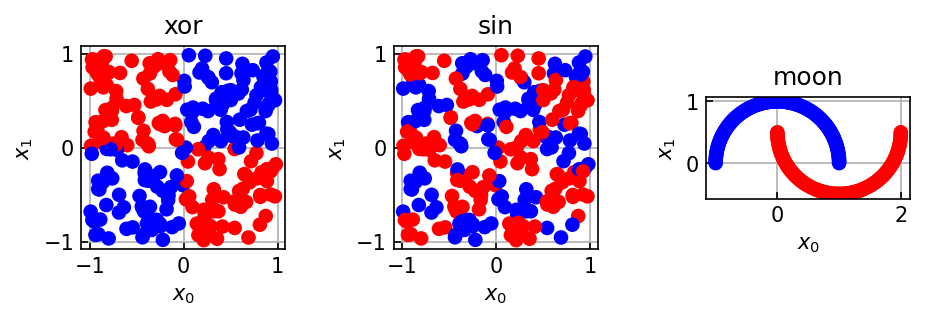

In [19]:
from sklearn.datasets import make_moons

def make_xor_dataset(N=256, random_seed=42):
    np.random.seed(random_seed)
    X = 2 * np.random.uniform(size=(N, 2)) - 1
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

def make_sin_dataset(N=1024, random_seed=42):
    np.random.seed(random_seed)
    X = 2 * np.random.uniform(size=(N, 2)) - 1
    y = np.sin(2 * np.pi * X[:, 0]) * np.cos(2 * np.pi * X[:, 1])
    y = np.where(y > 0, 1, 0)
    return X, y

nl_datasets = {
    'xor': make_xor_dataset(N=256),
    'sin': make_sin_dataset(N=256),
    'moon': make_moons(n_samples=256)
}

# Plot each of these datasets to see nonlinear character
fig, ax = plt.subplots(1, 3)

for ii, (label, (X_nl, y_nl)) in enumerate(nl_datasets.items()):
    ax[ii].scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr')
    ax[ii].set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal')
    ax[ii].set_title(label)

plt.tight_layout()

In [20]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.05, colors=['red', 'blue'], **kwargs):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min() - 10*d, X[:, 0].max() + 10*d, d),
        np.arange(X[:, 1].min() - 10*d, X[:, 1].max() + 10*d, d),
    )
    y_grid = model.predict(np.stack([x1.ravel(), x2.ravel()]).T) # [N, 2]
    y_grid = y_grid.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im = ax.pcolormesh(x1, x2, y_grid, cmap=cmap, alpha=0.5)

    for ii, label in enumerate(np.unique(y)):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[int(label)], **kwargs)

### Feature Ridge Regression

We are going to do linear ridge regression on a set of nonlinear features. Specifically, we would like to optimize 
\begin{align}
    \mathcal{L} = \sum_{i=1}^N (y_i - \hat{y_i})^2 + \lambda \vec{w} \cdot \vec{w}
\end{align}
where
\begin{align}
    y(x) &= \vec{w} \cdot \vec{\phi}(x) \\
         &= \left[ \sum_{i=1}^{N_{\text{train}}} \alpha_i \vec{\phi} (x_i) \right] \cdot \vec{\phi}(x)
\end{align}
In the second line, we have rewritten the parameter vector $\vec{w}$ as a weighted sum over training examples. Our goal will be to figure out the sample weights $\alpha_i$ and use them to compute $\vec{w}$

To do this, we can substitute in the "nearest neighbor feature regression" version of $y(x)$ into the objective function. Adopting a notation where the matrix $\Phi_{N\times f} = \left\{ \vec{\phi}(x_1); \vec{\phi}(x_2); \dots \right\}$, the vector $\vec{\alpha}_{N}$ contains the sample weights, and $\vec{w} = \Phi^{\top} \vec{\alpha}$ we get
\begin{align}
    \mathcal{L} &= \left(\Phi \vec{w} - \hat{Y}\right)^{\top} \left( \Phi \vec{w} - \hat{Y} \right) + \lambda \vec{w}^{\top} \vec{w} \\
    &= \left( \Phi \Phi^{\top} \vec{\alpha} - \hat{Y} \right)^{\top} \left( \Phi \Phi^{\top} \vec{\alpha} - \hat{Y} \right) + \lambda \vec{\alpha}^{\top} \Phi \Phi^{\top} \vec{\alpha} \\
\end{align}
We're going to adopt the shorthand $K_{N\times N} = \Phi \Phi^{\top}$, leading to
\begin{align}
    \mathcal{L} &= \vec{\alpha}^{\top} K K \vec{\alpha} - 2 \vec{\alpha}^{\top} K \hat{Y} + \hat{Y}^{\top}\hat{Y} + \lambda \vec{\alpha}^{\top} K \vec{\alpha}
\end{align}
The minimum loss solution is when $\partial_{\vec{\alpha}} \mathcal{L} = 0$
\begin{align}
    \frac{\partial \mathcal{L}}{\partial \vec{\alpha}} &= 0 \\
    &= 2 K K \vec{\alpha} - 2 K \hat{Y} + 2 \lambda K \vec{\alpha} \\
    \rightarrow K \hat{Y} &= K (K + \lambda I) \vec{\alpha} \\
    \rightarrow \vec{\alpha} &= (K + \lambda I)^{-1} \hat{Y}
\end{align}
We will use this result to compute $\vec{\alpha}$ during fitting and then compute our weights

In [21]:
from sklearn.preprocessing import PolynomialFeatures

class FeatureRidgeRegression:
    def __init__(self, feature_transform, ridge_weight=0.1):
        self.feature_transform = feature_transform
        self.ridge_weight = ridge_weight

    def fit(self, X, y):
        N, k = X.shape
        assert y.shape[0] == N

        X_feat = self.feature_transform.fit_transform(X) #[N, f]

        # Now compute the feature vector weights for each element of the training set
        alpha = np.dot(
            np.linalg.inv(np.matmul(X_feat, X_feat.T) + self.ridge_weight * np.eye(N)),
            y
        )

        # Now compute the weight vector as the weighted sum of training feature vectors
        self.w_ = np.sum(alpha[:, None] * X_feat, axis=0)

        return self
        

    def predict(self, X):
        X_feat = self.feature_transform.transform(X)
        y_pred = np.dot(X_feat, self.w_)
        return np.where(y_pred > 0.5, 1, 0)

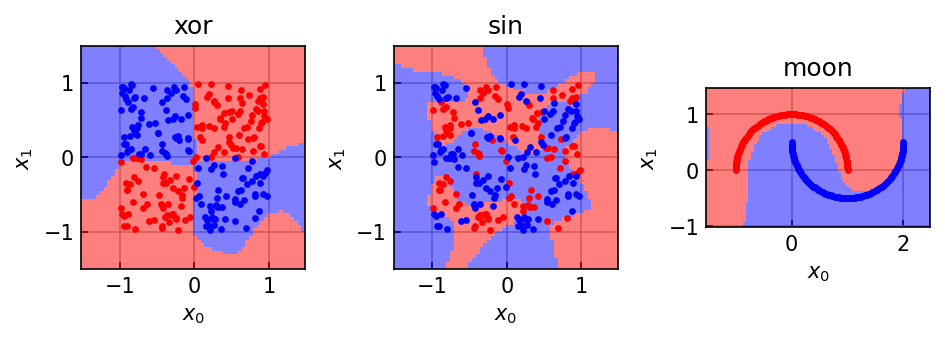

In [22]:
model = FeatureRidgeRegression(feature_transform=PolynomialFeatures(degree=10))

fig, ax = plt.subplots(1, 3)

for ii, (label, (X_nl, y_nl)) in enumerate(nl_datasets.items()):
    model.fit(X_nl, y_nl)
    
    plot_decision_boundary(ax[ii], X_nl, y_nl, model, s=5)    
    ax[ii].set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal')
    ax[ii].set_title(label)

plt.tight_layout()

### Kernel Ridge Regression

In the above example, we had to compute a matrix whose entries contained the dot products between feature vectors from our training set $\vec{\phi}(x_{\text{train}})$ The **kernel trick** recasts this dot product as the evaluation of a kernel function $k(x_i, x_j) = \vec{\phi}(x_i) \cdot \vec{\phi(x_j)}$. Using this trick, one can compute a kernel matrix $K \equiv \Phi \Phi^T$ whose entries consist of kernel evaluations
\begin{align}
    K_{ij} = k(x_i, x_j) = \vec{\phi}(x_i) \cdot \vec{\phi(x_j)}
\end{align}
In kernel ridge regression, we no longer care about the feature function and never compute feature vectors. Instead, we implicitly compute the product of feature vectors using the kernel function. The actual fitting will be almost identical as above. The main difference is that by using the kernel trick, the model evaluation becomes
\begin{align}
    y(x) = \sum_{i=1}^{N_{\text{train}}} \alpha_i\, k(x_i, x)
\end{align}
Thus, model inference requires evaluation of the kernel function using each training point.

In [23]:
from sklearn.metrics.pairwise import rbf_kernel

class KernelRidgeRegression:
    def __init__(self, kernel_function=rbf_kernel, ridge_weight=0.1):
        self.kernel_function = kernel_function
        self.ridge_weight = ridge_weight

    def fit(self, X, y):
        N, k = X.shape
        assert y.shape[0] == N

        self.X_ = X

        # Now compute the kernel matrix
        K_mat = self.kernel_function(X, X)

        # Now compute the feature vector weights for each element of the training set
        self.alpha_ = np.dot(
            np.linalg.inv(K_mat + self.ridge_weight * np.eye(N)),
            y
        )
        
        return self
        
    def predict(self, X):
        k = self.kernel_function(self.X_, X)
        y_pred = np.dot(self.alpha_, k)
        return np.where(y_pred > 0.5, 1, 0)

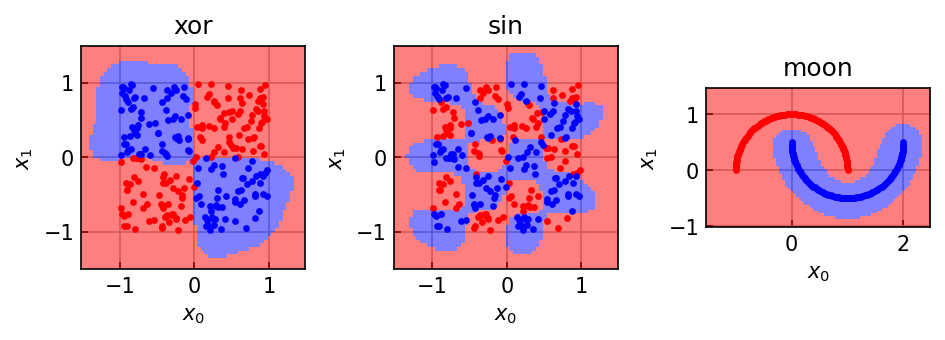

In [24]:
model = KernelRidgeRegression(kernel_function=lambda x1,x2: rbf_kernel(x1, x2, gamma=5.))

fig, ax = plt.subplots(1, 3)

for ii, (label, (X_nl, y_nl)) in enumerate(nl_datasets.items()):
    model.fit(X_nl, y_nl)
    
    plot_decision_boundary(ax[ii], X_nl, y_nl, model, s=5)    
    ax[ii].set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal')
    ax[ii].set_title(label)

plt.tight_layout()